In [ ]:
import pandas as pd
csv='./merged_with_emit_tag.csv'
df=pd.read_csv(csv)
print(len(df))
df=df.dropna(subset=['emit_-90_granule_id', 'emit_-180_granule_id', 'emit_granule_id'])
# df=df.dropna(subset=['emit_granule_id'])
print(len(df))

4244
3434


In [1]:
import os
import gc
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import cupy as cp
from pathlib import Path
from pyproj import Transformer
from scipy.spatial import KDTree as CPU_KDTree
from concurrent.futures import ProcessPoolExecutor
from functools import partial

# ==================== 用户配置区 ====================
CSV_PATH = "./merged_with_emit_tag.csv"
SRF_CSV = "./WV3_VNIR_SWIR_response.csv"
EMIT_RAW_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_EMIT")
OUTPUT_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/EMIT_simulated_WV3_L2A_60resolution_NOnorm")

CHIP_SIZE_PX = 512    
SCALE_M = 60          
MAX_WORKERS = 4  # 根据显存大小调整。如果显存 > 24G，可以设为 8 或更多。
# ===================================================

os.umask(0)
EMIT_RAW_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def get_utm_crs(lat, lon):
    zone = int((lon + 180) / 6) + 1
    return f"EPSG:{32600 + zone if lat >= 0 else 32700 + zone}"

def find_local_granule(granule_id):
    clean_id = str(granule_id).strip().replace('\r', '').replace('\n', '')
    search_pattern = f"*{clean_id}*.nc"
    existing = list(EMIT_RAW_DIR.glob(search_pattern))
    if existing:
        rfl_files = [f for f in existing if "RFL" in f.name and "UNCERT" not in f.name and "MASK" not in f.name]
        return rfl_files[0] if rfl_files else None
    return None

def process_single_task(row_tuple, srf_data):
    """ 单个任务的处理逻辑 """
    _, row = row_tuple
    plume_id = row['plume_id']
    out_tif = OUTPUT_DIR / f"{plume_id}_sim_WV3.tif"
    
    if out_tif.exists():
        return f"[Skip] {plume_id}"

    rfl_path = find_local_granule(row['emit_granule_id'])
    if not rfl_path:
        return f"[Error] Not found: {plume_id}"

    try:
        # 1. 空间裁剪
        with xr.open_dataset(rfl_path, group='location', engine='netcdf4') as ds_loc:
            lats, lons = ds_loc['lat'].values, ds_loc['lon'].values
            mask_spatial = (lats > row['plume_latitude'] - 0.15) & (lats < row['plume_latitude'] + 0.15) & \
                           (lons > row['plume_longitude'] - 0.15) & (lons < row['plume_longitude'] + 0.15)
            y_idxs, x_idxs = np.where(mask_spatial)
            if len(y_idxs) == 0: return f"[Empty] {plume_id}"
            
            y_min, y_max, x_min, x_max = y_idxs.min(), y_idxs.max(), x_idxs.min(), x_idxs.max()
            lat_crop, lon_crop = lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max]

        # 2. 读取反射率与光谱矩阵计算
        with xr.open_dataset(rfl_path, engine='netcdf4') as ds:
            rfl_crop = ds['reflectance'][y_min:y_max, x_min:x_max, :].values
        
        with xr.open_dataset(rfl_path, group='sensor_band_parameters') as dsb:
            emit_waves = dsb['wavelengths'].values

        # 计算 SRF 矩阵 (在进程内计算，保证 emit_waves 匹配)
        wv3_bands = ['Coastal (MS7)', 'Blue (MS4)', 'Green (MS3)', 'Yellow (MS6)', 'Red (MS2)', 
                     'Red Edge (MS5)', 'NIR1 (MS1)', 'NIR2 (MS8)', 'SWIR1', 'SWIR2', 'SWIR3', 
                     'SWIR4', 'SWIR5', 'SWIR6', 'SWIR7', 'SWIR8']
        srf_matrix = np.zeros((len(emit_waves), 16))
        for i, b in enumerate(wv3_bands):
            w = np.interp(emit_waves, srf_data['waves'], srf_data[b], left=0, right=0)
            srf_matrix[:, i] = w / (w.sum() + 1e-12)

        # 3. GPU 运算
        cp_rfl = cp.array(np.nan_to_num(rfl_crop, 0))
        cp_srf = cp.array(srf_matrix)
        sim_conv = cp.matmul(cp_rfl, cp_srf)
        
        target_scales = [10000] * 16
        cp_simulated_list = []
        for b in range(16):
            band_data = sim_conv[:, :, b]
            valid = (band_data > 0)
            if valid.any():
                p_low, p_high = cp.percentile(band_data[valid], 1), cp.percentile(band_data[valid], 99)
                stretched = (band_data - p_low) / (p_high - p_low + 1e-6)
                final_band = (stretched * (target_scales[b] * 0.6)) + (target_scales[b] * 0.8)
                final_band = cp.where(valid, final_band, 0)
            else:
                final_band = band_data
            cp_simulated_list.append(cp.clip(final_band, 0, 65535))
        
        cp_simulated = cp.stack(cp_simulated_list, axis=0)

        # 4. 空间重采样 (CPU KDTree)
        utm_epsg = get_utm_crs(row['plume_latitude'], row['plume_longitude'])
        to_utm = Transformer.from_crs("EPSG:4326", utm_epsg, always_xy=True)
        to_wgs = Transformer.from_crs(utm_epsg, "EPSG:4326", always_xy=True)
        
        cx, cy = to_utm.transform(row['plume_longitude'], row['plume_latitude'])
        hs = (CHIP_SIZE_PX * SCALE_M) / 2
        tx, ty = np.linspace(cx-hs, cx+hs, CHIP_SIZE_PX), np.linspace(cy+hs, cy-hs, CHIP_SIZE_PX)
        mx, my = np.meshgrid(tx, ty)
        t_lon, t_lat = to_wgs.transform(mx, my)
        
        tree = CPU_KDTree(np.stack([lat_crop.ravel(), lon_crop.ravel()], axis=1))
        dist, idxs = tree.query(np.stack([t_lat.ravel(), t_lon.ravel()], axis=1), distance_upper_bound=0.001)
        
        # 5. 映射输出
        res = cp_simulated.reshape(16, -1)[:, cp.array(idxs)].reshape(16, CHIP_SIZE_PX, CHIP_SIZE_PX)
        res[:, cp.array(dist == float('inf')).reshape(CHIP_SIZE_PX, CHIP_SIZE_PX)] = 0
        
        res_np = res.get().astype(np.uint16)
        sim_da = xr.DataArray(res_np, dims=("band", "y", "x"), coords={"band": np.arange(1, 17), "y": ty, "x": tx})
        sim_da.rio.write_crs(utm_epsg, inplace=True).rio.to_raster(out_tif)

        # 显存清理
        del cp_rfl, cp_srf, sim_conv, cp_simulated, res, res_np
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()
        
        return f"[Success] {plume_id}"
    except Exception as e:
        return f"[Error] {plume_id}: {str(e)}"

def main():
    df = pd.read_csv(CSV_PATH)
    srf_df = pd.read_csv(SRF_CSV)
    
    # 预加载 SRF 数据到字典，避免进程间传递大型 DataFrame
    wv3_bands = ['Coastal (MS7)', 'Blue (MS4)', 'Green (MS3)', 'Yellow (MS6)', 'Red (MS2)', 
                 'Red Edge (MS5)', 'NIR1 (MS1)', 'NIR2 (MS8)', 'SWIR1', 'SWIR2', 'SWIR3', 
                 'SWIR4', 'SWIR5', 'SWIR6', 'SWIR7', 'SWIR8']
    srf_data = {b: srf_df[b].values for b in wv3_bands}
    srf_data['waves'] = srf_df['nm/Band'].values

    # mask = (df['plume_latitude'] >= 30) & (df['plume_latitude'] <= 35) & (df['has_emit'] == 1)
    # tasks = list(df[mask].iterrows())
    tasks = list(df.iterrows())
    
    print(f"Starting parallel processing for {len(tasks)} tasks with {MAX_WORKERS} workers...")

    # 使用多进程池
    worker_func = partial(process_single_task, srf_data=srf_data)
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        for result in executor.map(worker_func, tasks):
            print(result)

if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'cupy'

In [ ]:
import pandas as pd
CSV_PATH = "./merged_with_emit_tag.csv"  
df = pd.read_csv(CSV_PATH)
df=df.dropna(subset=['emit_-90_granule_id', 'emit_granule_id'])
df=df.dropna(subset=['emit_-180_granule_id'])

# --- 应用指定的 Mask 区域 ---
# mask_condition = (df['plume_latitude'] >= 30) & (df['plume_latitude'] <= 35) & (df['has_emit'] == 1)
# target_df = df[mask_condition].copy()
# target_df=target_df['emit_granule_id'].dropna()
# target_df.to_csv("./merged_with_emit_tag_permian_basin.csv")
# print(len(target_df))

1264


In [ ]:
import pandas as pd

# 1) 读数据（有经纬度 + 时间）
df = pd.read_csv("./merged_with_emit_tag.csv")
# df = pd.read_csv("./CM_L89_L2SR_std512.csv")
# df = pd.read_csv("./l89_emit_overlap_summary.csv")

# 2) Permian basin bbox（请替换为你认可的范围）
# 示例：min_lon, max_lon, min_lat, max_lat
min_lon, max_lon = -105.5, -100.0
min_lat, max_lat =  30.0,  34.5

# 3) 时间过滤（2024-12-31 以前）
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
time_mask = df["datetime"] < pd.Timestamp("2024-12-31T23:59:59Z")

# 4) 空间过滤（Permian basin）
space_mask = (
    (df["plume_longitude"] >= min_lon) & (df["plume_longitude"] <= max_lon) &
    (df["plume_latitude"]  >= min_lat) & (df["plume_latitude"]  <= max_lat)
)
df=df[time_mask & space_mask]
# df.to_csv("./emit_permian_basin_2024.csv", index=False)
count = (time_mask & space_mask).sum()
print("Permian basin 且 2024-12-31 以前的数据数量:", int(count))

Permian basin 且 2024-12-31 以前的数据数量: 550


In [11]:
import pandas as pd
import os

# Paths
EMIT_SIM_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9"
CSV_PATH = "./emit_permian_basin_2024.csv" # Your CSV with the columns provided
MASK_ROOT = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512"

df = pd.read_csv(CSV_PATH)

def get_paths(pid):
    sim_tif = os.path.join(EMIT_SIM_DIR, f"{pid}_sim_L9.tif")
    mask_tif = os.path.join(MASK_ROOT, str(pid), 'mask_30m_512.tif')
    return sim_tif if os.path.exists(sim_tif) else None, mask_tif if os.path.exists(mask_tif) else None

df[['sim_path', 'mask_path']] = df['plume_id'].apply(lambda x: pd.Series(get_paths(x)))
df = df.dropna(subset=['sim_path', 'mask_path'])
df.to_csv(CSV_PATH, index=False)

In [4]:
df=pd.read_csv("./wv3_merged_with_simulated_path_permian_basin.csv")
df=df.dropna(subset=['simulated_512_path'])
df.to_csv("./wv3_merged_with_simulated_path_permian_basin.csv")
print(len(df))

1284


In [5]:
import os
import pandas as pd
import numpy as np
import tifffile
import random
import torch
import torch.nn.functional as F
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import threading

# =========================
# Config
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Updated Directory Name
BASE_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/EMIT_simulated_WV3_L2A_60resolution_NOnorm"
INPUT_CSV = "./wv3_merged_with_simulated_path_permian_basin.csv"
MANIFEST_PATH = os.path.join(BASE_DIR, "dataset_manifest.csv")

CROP_SIZE = 32       
TARGET_SIZE = 224    
MISSING_THRESH = 0.25
N_POS, N_NEG = 16, 16
NUM_WORKERS = 8
CENTER_BOX = 8      # How much the "center" can jiggle (at 60m pixels)

os.makedirs(BASE_DIR, exist_ok=True)
counter_lock = threading.Lock()
global_cnt = 0

# =========================
# Helpers
# =========================

def ensure_chw(img):
    if img.ndim == 2: return img[np.newaxis, ...]
    if img.ndim == 3 and img.shape[0] > img.shape[2]: return img.transpose(2, 0, 1)
    return img

def upsample_to_224(crop_np):
    with torch.no_grad():
        img_t = torch.from_numpy(crop_np.astype(np.float32)).to(DEVICE).unsqueeze(0)
        img_t = torch.nan_to_num(img_t, nan=0.0)
        upsampled = F.interpolate(img_t, size=(TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
        return upsampled.squeeze(0).cpu().numpy()

# =========================
# Worker Core Logic
# =========================

def worker(row):
    global global_cnt
    local_results = []
    pid = row["plume_id"]
    sim_path = row["simulated_512_path"]

    # Debug check
    if not os.path.exists(sim_path):
        return []

    try:
        ref_60m = ensure_chw(tifffile.imread(sim_path).astype(np.float32))
        _, H, W = ref_60m.shape
    except Exception:
        return []

    # Center coordinates logic (assuming plume is at 256, 256)
    # Range of top-left corners that keep the center inside the 32x32 crop
    p_min = (H // 2) - (CROP_SIZE // 2) - (CENTER_BOX // 2)
    p_max = (H // 2) - (CROP_SIZE // 2) + (CENTER_BOX // 2)

    # --- POSITIVE SAMPLES (Always Labeled 1) ---
    for _ in range(N_POS):
        # Randomly jiggle the crop around the center
        x, y = random.randint(p_min, p_max), random.randint(p_min, p_max)
        
        ref_crop = ref_60m[:, y:y+CROP_SIZE, x:x+CROP_SIZE]
        
        # Quality check only (no mask check)
        if ref_crop.size == 0 or (np.isnan(ref_crop[0]) | (ref_crop[0] == 0)).mean() > MISSING_THRESH:
            continue
            
        final_ref = upsample_to_224(ref_crop)

        with counter_lock:
            global_cnt += 1
            sample_id = global_cnt
        
        sample_dir = os.path.join(BASE_DIR, f"sample_{sample_id:06d}")
        os.makedirs(sample_dir, exist_ok=True)
        
        # Feature names modified as requested
        tifffile.imwrite(os.path.join(sample_dir, "reflectance_60m_upsampled.tif"), final_ref)

        local_results.append({
            "sample_id": sample_id, 
            "label": 1, 
            "plume_id": pid,
            "data_path": sample_dir, 
            "timestamp": row["datetime"]
        })

    # --- NEGATIVE SAMPLES (Labeled 0) ---
    neg_attempts = 0
    while len(local_results) < (N_POS + N_NEG) and neg_attempts < 100:
        neg_attempts += 1
        x, y = random.randint(0, W - CROP_SIZE), random.randint(0, H - CROP_SIZE)
        
        # Avoid the center plume area (buffer of 10 pixels)
        if (p_min - 10 <= x <= p_max + 10) and (p_min - 10 <= y <= p_max + 10):
            continue

        ref_crop = ref_60m[:, y:y+CROP_SIZE, x:x+CROP_SIZE]
        if ref_crop.size == 0 or (np.isnan(ref_crop[0]) | (ref_crop[0] == 0)).mean() > MISSING_THRESH:
            continue

        final_ref = upsample_to_224(ref_crop)
        
        with counter_lock:
            global_cnt += 1
            sample_id = global_cnt

        sample_dir = os.path.join(BASE_DIR, f"sample_{sample_id:06d}")
        os.makedirs(sample_dir, exist_ok=True)
        
        tifffile.imwrite(os.path.join(sample_dir, "reflectance_60m_upsampled.tif"), final_ref)
        
        local_results.append({
            "sample_id": sample_id, 
            "label": 0, 
            "plume_id": pid,
            "data_path": sample_dir, 
            "timestamp": row["datetime"]
        })

    return local_results

# =========================
# Main
# =========================

def process_all():
    global global_cnt
    df = pd.read_csv(INPUT_CSV)
    
    # Filter to unique events if you want to avoid processing -A, -G, -T separately
    # df['prefix'] = df['plume_id'].str.split('-').str[0]
    # df = df.drop_duplicates(subset=['prefix'])

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        rows = [row for _, row in df.iterrows()]
        batch_results = list(tqdm(executor.map(worker, rows), total=len(rows)))

    all_results = [res for sublist in batch_results for res in sublist]
    
    if all_results:
        final_df = pd.DataFrame(all_results)
        final_df.to_csv(MANIFEST_PATH, index=False)
        print(f"Success. Generated {len(final_df)} classification samples.")
    else:
        print("No samples generated. Check paths.")

if __name__ == "__main__":
    process_all()

100%|██████████| 1284/1284 [21:18<00:00,  1.00it/s]


Success. Generated 40857 classification samples.


In [ ]:
# mask alignment for WV3
import pandas as pd
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
from pyproj import Transformer
from tqdm import tqdm

# =========================
# 配置 (根据你的环境修改)
# =========================
# EMIT / WV3 合并后的 CSV（只有 plume_id/lat/lon/emit_* 等，没有 simulated_512_path）
EMIT_CSV = './merged_with_emit_tag.csv'

# 原始高分辨率航空掩膜的存储根目录（plume.tif）
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'

# WV3 模拟 512x512 影像所在目录（EMIT_wv3.py / _90 / _180 输出）
SIM_OUTPUT_DIR = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/EMIT_simulated_WV3_L2A_60resolution_NOnorm'

# 目标输出目录：生成的 60m 512x512 WV3 掩膜
OUT_MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_masks_wv3_512'

TARGET_RES = 60   # WV3 模拟像元大小 (米)
TARGET_SIZE = 512

# =========================
# 核心处理函数
# =========================

def process_wv3_mask(plume_id, center_lat, center_lon, ref_tif_path):
    """
    使用 WV3 模拟影像 ref_tif_path 的 CRS，将航空 plume.tif 重投影并对齐到 60m 512x512 网格。
    """
    dst_path = os.path.join(OUT_MASK_ROOT, plume_id, 'mask_60m_512.tif')
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    # 输入掩膜：高分辨率航空 plume.tif
    input_tif = os.path.join(BASE_AIRBORNE_DIR, plume_id, 'plume.tif')

    if not os.path.exists(input_tif):
        return False, f"Source mask missing: {input_tif}"
    if not os.path.exists(ref_tif_path):
        return False, f"Reference WV3 sim missing: {ref_tif_path}"

    try:
        # 1. WV3 模拟影像的 CRS & transform
        with rasterio.open(ref_tif_path) as ref:
            target_crs = ref.crs
            ref_transform = ref.transform
            ref_height, ref_width = ref.height, ref.width

        with rasterio.open(input_tif) as src:
            if src.height == 0 or src.width == 0:
                return False, "Empty source TIFF"

            # 2. 经纬度 -> WV3 投影坐标
            transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
            center_x, center_y = transformer.transform(center_lon, center_lat)

            # 3. Grid snapping：保证 mask 像素中心落在 60m 网格上
            center_x = round(center_x / TARGET_RES) * TARGET_RES
            center_y = round(center_y / TARGET_RES) * TARGET_RES

            # 4. 以中心为 (TARGET_SIZE/2, TARGET_SIZE/2) 计算左上角
            top_left_x = center_x - (TARGET_SIZE // 2) * TARGET_RES
            top_left_y = center_y + (TARGET_SIZE // 2) * TARGET_RES

            new_transform = Affine(TARGET_RES, 0, top_left_x,
                                   0, -TARGET_RES, top_left_y)

            # 5. 输出数组
            out_mask = np.zeros((1, TARGET_SIZE, TARGET_SIZE), dtype='uint8')

            # 6. 重投影到 WV3 CRS+网格
            reproject(
                source=rasterio.band(src, 1),
                destination=out_mask[0],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest
            )

            # 7. 写出 GTiff
            profile = src.profile.copy()
            profile.update(
                driver='GTiff',
                transform=new_transform,
                crs=target_crs,
                width=TARGET_SIZE,
                height=TARGET_SIZE,
                count=1,
                dtype='uint8',
                compress='lzw',
                nodata=0
            )

            with rasterio.open(dst_path, 'w', **profile) as dst:
                dst.write(out_mask)

            return True, "Success"

    except Exception as e:
        return False, str(e)

# =========================
# 主程序
# =========================

if __name__ == "__main__":
    print(f"Loading source data from {EMIT_CSV}...")
    df = pd.read_csv(EMIT_CSV)

    # 如果没有 simulated_512_path 列（merged_with_emit_tag 没有），根据 plume_id 自动构造
    if "simulated_512_path" not in df.columns:
        df["simulated_512_path"] = df["plume_id"].astype(str).apply(
            lambda pid: os.path.join(SIM_OUTPUT_DIR, f"{pid}_sim_WV3.tif")
        )

    # 只保留 WV3 模拟影像真实存在的 plume
    work_df = df[df["simulated_512_path"].apply(
        lambda p: isinstance(p, str) and os.path.exists(p)
    )].copy()

    print(f"Total plumes to process: {len(work_df)}")

    results = []
    for index, row in tqdm(work_df.iterrows(), total=len(work_df)):
        pid = row['plume_id']
        lat = row['plume_latitude']
        lon = row['plume_longitude']
        ref_path = row['simulated_512_path']  # WV3 模拟影像路径

        # 可选：排除已知异常 plume
        if pid == 'GAO20210515t145818p0000-1':
            continue

        success, msg = process_wv3_mask(pid, lat, lon, ref_path)
        if not success:
            results.append({"plume_id": pid, "error": msg})

    if results:
        error_df = pd.DataFrame(results)
        error_df.to_csv('mask_gen_errors_wv3.csv', index=False)
        print(f"\nDone. Errors encountered: {len(results)}. See mask_gen_errors_wv3.csv")
    else:
        print("\nDone. All WV3 masks generated and aligned successfully.")


In [6]:
import pandas as pd

# 读csv（换成你的路径）
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/EMIT_simulated_WV3_L2A_60resolution_NOnorm/dataset_manifest.csv")

# 拼接新列
df["path_t0"] = df["data_path"].astype(str) + "/reflectance_60m_upsampled.tif"

# 保存
df.to_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/EMIT_simulated_WV3_L2A_60resolution_NOnorm/dataset_manifest.csv", index=False)

print(df[["path_t0"]].head())

                                             path_t0
0  /mnt/engg-leung/Research_No9_Methane_Emissions...
1  /mnt/engg-leung/Research_No9_Methane_Emissions...
2  /mnt/engg-leung/Research_No9_Methane_Emissions...
3  /mnt/engg-leung/Research_No9_Methane_Emissions...
4  /mnt/engg-leung/Research_No9_Methane_Emissions...


In [14]:
import pandas as pd

# 路径
manifest_path = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/dataset_manifest_temporal.csv"
emit_csv_path = "./merged_with_emit_tag.csv"   # 相对 EMIT_wv3.ipynb 所在目录

# 1) 读入 manifest
df_man = pd.read_csv(manifest_path)

# 2) 读入原始 CSV，只保留 plume_id 和 datetime，并按 plume_id 去重
df_emit = (
    pd.read_csv(emit_csv_path, usecols=["plume_id", "datetime", "plume_latitude", "plume_longitude"])
      .drop_duplicates(subset="plume_id")
      .rename(columns={"datetime": "timestamp"})  # 想直接叫 datetime 就把这一行删掉
)

# 3) 按 plume_id 合并
df_merged = df_man.merge(df_emit, on="plume_id", how="left")

# 4) 回写（覆盖原文件，或改成别的文件名保存）
df_merged.to_csv(manifest_path, index=False)


In [1]:
import pandas as pd
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/dataset_manifest_temporal.csv")
# print(df2.head())
# df2['date'] = pd.to_datetime(df2['datetime'])
# train_df = df[(df['date'] < '2024-04-10') | (df['date'] >= '2025-01-01')]  # 2025-04-01
# test_df = df[(df['date'] >= '2024-04-10') & (df['date'] < '2025-01-01')]
# train_df = df[(df['timestamp'] < '2024-09-13')]  # 2025-04-01
# test_df = df[(df['timestamp'] >= '2024-09-13') & (df['timestamp'] <= '2024-12-31')]
train_df = df[(df['timestamp'] < '2025-05-01')]  # 2025-04-01
test_df = df[(df['timestamp'] >= '2025-05-01')]
print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')

import numpy as np
import pandas as pd

def balance_01(df, seed=42):
    pos = df[df["label"] == 1]
    neg = df[df["label"] == 0]

    # 只保留和正样本一样多的负样本
    neg_sampled = neg.sample(n=len(pos), random_state=seed)

    df_bal = pd.concat([pos, neg_sampled], axis=0)
    df_bal = df_bal.sample(frac=1, random_state=seed).reset_index(drop=True)  # 打乱
    return df_bal

train_df_bal = balance_01(train_df, seed=42)
test_df_bal  = balance_01(test_df,  seed=42)

print(train_df_bal["label"].mean(), test_df_bal["label"].mean())
print(train_df["label"].mean(), test_df["label"].mean())
# 基本接近 0.5 / 0.5

# train_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/train_2024.csv'
# train_df_bal.to_csv(train_csv, index=False)
# print(f'train set size {len(train_df_bal)}')

# test_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/test_2024.csv'
# test_df_bal.to_csv(test_csv, index=False)
# print(f'test set size {len(test_df_bal)}')

print(train_df['label'].sum()/len(train_df), test_df['label'].sum()/len(test_df))

training set 55105 testing set 9919 train ratio 0.847
0.5 0.5
0.44377098266944925 0.4317975602379272
0.44377098266944925 0.4317975602379272


In [5]:
import pandas as pd
df_sim=pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/dataset_manifest.csv")
df_real=pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/dataset_manifest_permian_basin.csv")
df_real = df_real[df_sim.columns]
df=pd.concat([df_sim,df_real],ignore_index=True)
train_df_sim = df_sim[(df_sim['datetime'] < '2023-10-25') & (df_sim['datetime'] > '2023-08-21')]  # 2025-04-01
test_df_sim = df_sim[(df_sim['datetime'] >= '2023-10-25') & (df_sim['datetime'] <= '2024-12-31')]
print(f'sim training set {len(train_df_sim)} testing set {len(test_df_sim)} train ratio {len(train_df_sim)/(len(train_df_sim)+len(test_df_sim)):.3f}')
train_df_real = df_real[(df_real['datetime'] < '2024-05-13')]  # 2025-04-01
test_df_real = df_real[(df_real['datetime'] >= '2024-05-13') & (df_real['datetime'] <= '2024-12-31')]
print(f'real training set {len(train_df_real)} testing set {len(test_df_real)} train ratio {len(train_df_real)/(len(train_df_real)+len(test_df_real)):.3f}')
train_df = pd.concat([train_df_sim, train_df_real], ignore_index=True)
test_df = pd.concat([test_df_sim, test_df_real], ignore_index=True)
print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')
# id,label,plume_id,path,datetime
# id,label,plume_id,path,latitude,longitude,datetime,path_t0,path_t90,path_t360

# train_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/train_sim_real_mix_permian.csv'
# train_df.to_csv(train_csv, index=False)
# print(f'train set size {len(train_df)}')

# test_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/test_sim_real_mix_permian.csv'
# test_df.to_csv(test_csv, index=False)
# print(f'test set size {len(test_df)}')

# train_sim_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/train_sim_permian.csv'
# train_df_sim.to_csv(train_sim_csv, index=False)
# print(f'train set size {len(train_df_sim)}')

# test_sim_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/test_sim_permian.csv'
# test_df_sim.to_csv(test_sim_csv, index=False)
# print(f'test set size {len(test_df_sim)}')

print(train_df_sim['label'].sum()/len(train_df_sim), test_df_sim['label'].sum()/len(test_df_sim))

KeyError: "['sample_id', 'data_path', 'timestamp'] not in index"

In [23]:
import os
import gc
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import earthaccess
import cupy as cp
from pathlib import Path
from pyproj import Transformer
from scipy.spatial import KDTree as CPU_KDTree

# ==================== 用户配置区 ====================
CSV_PATH = "./merged_with_emit_tag.csv"
SRF_CSV = "./landsat9_oli_srf.csv"
EMIT_RAW_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_EMIT")
# OUTPUT_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution")
OUTPUT_DIR = Path("./")
CHIP_SIZE_PX = 512
SCALE_M = 60
# ===================================================

EMIT_RAW_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def get_utm_crs(lat, lon):
    zone = int((lon + 180) / 6) + 1
    return f"EPSG:{32600 + zone if lat >= 0 else 32700 + zone}"

def get_spectral_matrix_physics(emit_waves, srf_df, solar_irr_nc=None):
    """
    计算考虑太阳能量分布的光谱矩阵
    """
    if solar_irr_nc is not None:
        solar_irr = solar_irr_nc
    else:
        # 如果nc文件里没有，构造简易太阳曲线：可见光(500nm附近)最强，SWIR逐渐减弱
        print("   [Info] No solar_irradiance in NC, using empirical solar curve.")
        solar_irr = np.ones_like(emit_waves)
        solar_irr[emit_waves < 400] = 1.5
        solar_irr[(emit_waves >= 400) & (emit_waves < 700)] = 2.0 
        solar_irr[(emit_waves >= 700) & (emit_waves < 1300)] = 1.2
        solar_irr[(emit_waves >= 1300) & (emit_waves < 1900)] = 0.6
        solar_irr[emit_waves >= 1900] = 0.3

    matrix = np.zeros((len(emit_waves), 7))
    for i in range(1, 8):
        srf_interp = np.interp(emit_waves, srf_df["wavelength"], srf_df[f"b{i}"], left=0, right=0)
        # 物理权重 = 响应函数 * 太阳辐照度
        weight = srf_interp * solar_irr
        denom = weight.sum()
        if denom > 0:
            matrix[:, i-1] = weight / denom
            
    return cp.array(matrix)

def process_single_plume(plume_id_target, df, srf_df):
    # 查找CSV中的元数据
    target_rows = df[df['plume_id'] == plume_id_target]
    if target_rows.empty:
        print(f"   [Error] {plume_id_target} not found in CSV.")
        return
    row = target_rows.iloc[0]

    # 硬编码你指定的 NC 路径
    rfl_path = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_EMIT/EMIT_L2A_RFL_001_20230824T175337_2323612_023.nc"
    out_tif = OUTPUT_DIR / f"{plume_id_target}_sim_L9_physics.tif"
    
    print(f"\n[Processing Case] {plume_id_target}")

    try:
        # 1. 获取波段参数和辐照度
        solar_irr = None
        with xr.open_dataset(rfl_path, group='sensor_band_parameters') as dsb:
            waves = dsb['wavelengths'].values
            if 'solar_irradiance' in dsb:
                solar_irr = dsb['solar_irradiance'].values
            spec_matrix = get_spectral_matrix_physics(waves, srf_df, solar_irr)

        # 2. 空间裁剪范围
        with xr.open_dataset(rfl_path, group='location') as ds_loc:
            lats, lons = ds_loc['lat'].values, ds_loc['lon'].values
            mask_spatial = (lats > row['plume_latitude'] - 0.15) & (lats < row['plume_latitude'] + 0.15) & \
                           (lons > row['plume_longitude'] - 0.15) & (lons < row['plume_longitude'] + 0.15)
            y_idxs, x_idxs = np.where(mask_spatial)
            y_min, y_max, x_min, x_max = y_idxs.min(), y_idxs.max(), x_idxs.min(), x_idxs.max()
            lat_crop, lon_crop = lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max]

        # 3. 加载反射率数据
        with xr.open_dataset(rfl_path) as ds:
            rfl_crop = ds['reflectance'][y_min:y_max, x_min:x_max, :].values

        # 4. GPU 卷积与【关键】对比度拉伸
        cp_rfl = cp.array(np.nan_to_num(rfl_crop, 0))
        # sim_result = cp.matmul(cp_rfl, spec_matrix) # (Y, X, 7)
        sim_result = cp_rfl
        
        target_scales = [10100, 11100, 13100, 16100, 20100, 23100, 21100]
        # 对每个波段分别进行 2%-98% 线性拉伸，增加方差（让直方图变宽）
        cp_simulated_list = []
        for b in range(7):
            band_data = sim_result[:, :, b]
            # 剔除 0 值后再计算百分位，防止背景干扰
            valid_mask = (band_data > 0)
            if valid_mask.any():
                p_low = cp.percentile(band_data[valid_mask], 1)
                p_high = cp.percentile(band_data[valid_mask], 99)
            else:
                p_low, p_high = 0, 1

            # 线性拉伸
            stretched = (band_data - p_low) / (p_high - p_low + 1e-6)
            
            # 使用对应波段的目标量级进行缩放，并加上一个基础偏移量
            # 基础偏移量（Offset）是为了让直方图的左侧对齐蓝色的左侧
            offset = target_scales[b] * 0.8  
            final_band = (stretched * (target_scales[b] * 0.6)) + offset
            
            cp_simulated_list.append(cp.clip(final_band, 0, 65535))
        
        # 堆叠回 (7, Y, X)
        cp_simulated = cp.stack(cp_simulated_list, axis=0)

        # 5. KDTree 重采样
        utm_epsg = get_utm_crs(row['plume_latitude'], row['plume_longitude'])
        to_utm = Transformer.from_crs("EPSG:4326", utm_epsg, always_xy=True)
        to_wgs = Transformer.from_crs(utm_epsg, "EPSG:4326", always_xy=True)
        
        center_x, center_y = to_utm.transform(row['plume_longitude'], row['plume_latitude'])
        half_size = (CHIP_SIZE_PX * SCALE_M) / 2
        target_x = np.linspace(center_x - half_size, center_x + half_size, CHIP_SIZE_PX)
        target_y = np.linspace(center_y + half_size, center_y - half_size, CHIP_SIZE_PX)
        
        mesh_x, mesh_y = np.meshgrid(target_x, target_y)
        t_lon, t_lat = to_wgs.transform(mesh_x, mesh_y)
        
        tree = CPU_KDTree(np.stack([lat_crop.ravel(), lon_crop.ravel()], axis=1))
        dist, indices = tree.query(np.stack([t_lat.ravel(), t_lon.ravel()], axis=1), distance_upper_bound=0.001)
        
        # 6. 映射与保存
        cp_indices = cp.array(indices)
        final_output = cp_simulated.reshape(7, -1)[:, cp_indices].reshape(7, CHIP_SIZE_PX, CHIP_SIZE_PX)
        invalid_mask = cp.array(dist == float('inf')).reshape(CHIP_SIZE_PX, CHIP_SIZE_PX)
        final_output[:, invalid_mask] = 0
        
        res_np = final_output.get().astype(np.uint16)

        sim_da = xr.DataArray(res_np, dims=("band", "y", "x"), 
                             coords={"band": np.arange(1, 8), "y": target_y, "x": target_x})
        sim_da.rio.write_crs(utm_epsg, inplace=True)
        sim_da.rio.to_raster(out_tif)
        
        print(f"   [Success] Saved to: {out_tif}")
        print(f"   [Stats] Min: {res_np.min()}, Max: {res_np.max()}, Mean: {res_np.mean():.1f}")

    except Exception as e:
        print(f"   [Error] {plume_id_target} failed: {e}")
    finally:
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

if __name__ == "__main__":
    df = pd.read_csv(CSV_PATH)
    srf_df = pd.read_csv(SRF_CSV)
    
    # 运行指定案例
    test_id = "GAO20230824t160435p0000-C"
    process_single_plume(test_id, df, srf_df)


[Processing Case] GAO20230824t160435p0000-C
   [Info] No solar_irradiance in NC, using empirical solar curve.
   [Success] Saved to: GAO20230824t160435p0000-C_sim_L9_physics.tif
   [Stats] Min: 0, Max: 52359, Mean: 15281.7


Real data has 10 bands, slicing to first 7.


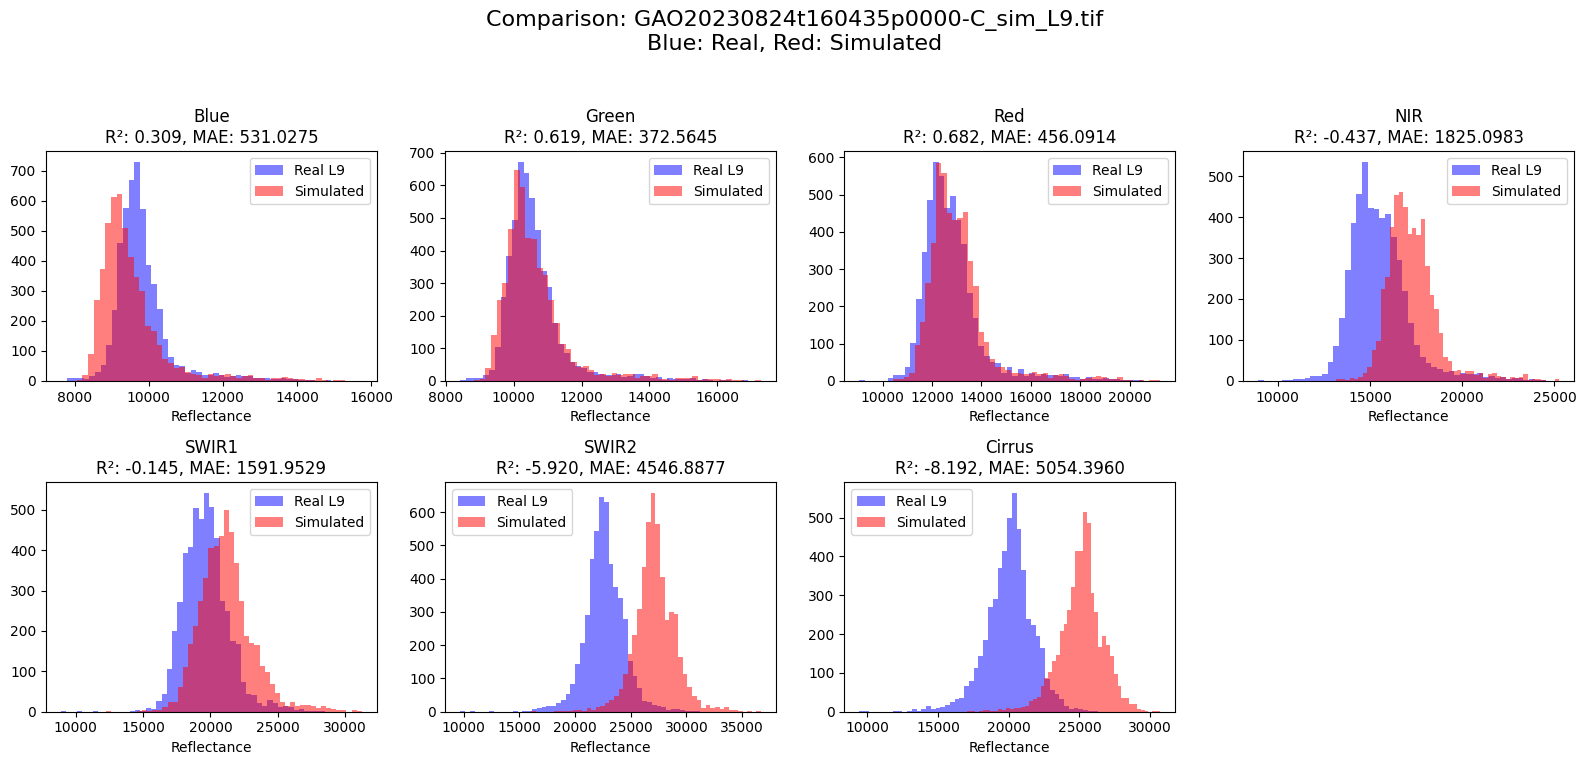

In [6]:
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import os

def compare_landsat_sim(sim_path, real_path):
    # 1. 读取数据
    sim_da = rioxarray.open_rasterio(sim_path)
    real_da = rioxarray.open_rasterio(real_path)

    # 【核心修改】：强制只取前 7 个波段
    # 如果 real_da 维度是 (band, y, x)，我们切片取 [:7]
    if real_da.shape[0] > 7:
        print(f"Real data has {real_da.shape[0]} bands, slicing to first 7.")
        real_da = real_da.isel(band=slice(0, 7))
    elif real_da.shape[0] < 7:
        print(f"Warning: Real data only has {real_da.shape[0]} bands!")

    # 2. 空间对齐 (将 Landsat 重采样到模拟数据的网格上)
    # real_aligned 的维度将与 sim_da 完全一致
    real_aligned = real_da.rio.reproject_match(sim_da)

    # 3. 提取数值
    sim_val = sim_da.values
    real_val = real_aligned.values
    
    # sim_val = sim_val * 10000.0 # 临时放大模拟值用于绘图
    
    # 自动缩放 Landsat：如果是 0-10000 的 Uint16，转为 0-1
    if real_val.max() > 10:
        print("Scaling Real data from digital numbers to reflectance (0-1)...")
        real_val = real_val / 10000.0

    # 4. 统计对比
    bands = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "Cirrus"]
    plt.figure(figsize=(16, 8))

    # 确定实际可对比的波段数，防止数组越界
    num_to_compare = min(7, sim_val.shape[0], real_val.shape[0])

    for i in range(num_to_compare):
        # 掩膜处理：剔除无效值（0 或 NaN）
        # 这一步很关键，如果不剔除背景 0 值，R² 会因为包含大量背景而虚高
        mask_i = (sim_val[i] > 0) & (real_val[i] > 0) & \
                 (~np.isnan(sim_val[i])) & (~np.isnan(real_val[i]))
        
        b_sim = sim_val[i][mask_i]
        b_real = real_val[i][mask_i]
        
        if b_sim.size < 10: 
            print(f"Band {i+1} ({bands[i]}) has no overlapping valid pixels.")
            continue

        r2 = r2_score(b_real, b_sim)
        mae = np.mean(np.abs(b_real - b_sim))

        # 绘图：直方图对比
        plt.subplot(2, 4, i+1)
        plt.hist(b_real.ravel(), bins=50, alpha=0.5, label='Real L9', color='blue')
        plt.hist(b_sim.ravel(), bins=50, alpha=0.5, label='Simulated', color='red')
        plt.title(f"{bands[i]}\nR²: {r2:.3f}, MAE: {mae:.4f}")
        plt.xlabel("Reflectance")
        plt.legend()

    sim_filename = os.path.basename(sim_path) # 获取文件名
    plt.suptitle(f"Comparison: {sim_filename}\nBlue: Real, Red: Simulated", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 调用示例
compare_landsat_sim(
    "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm/GAO20230824t160435p0000-C_sim_L9.tif", 
    "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/L89_-790360_512std/GAO20230824t160435p0000-C/l89_0_std_512.tif"
)

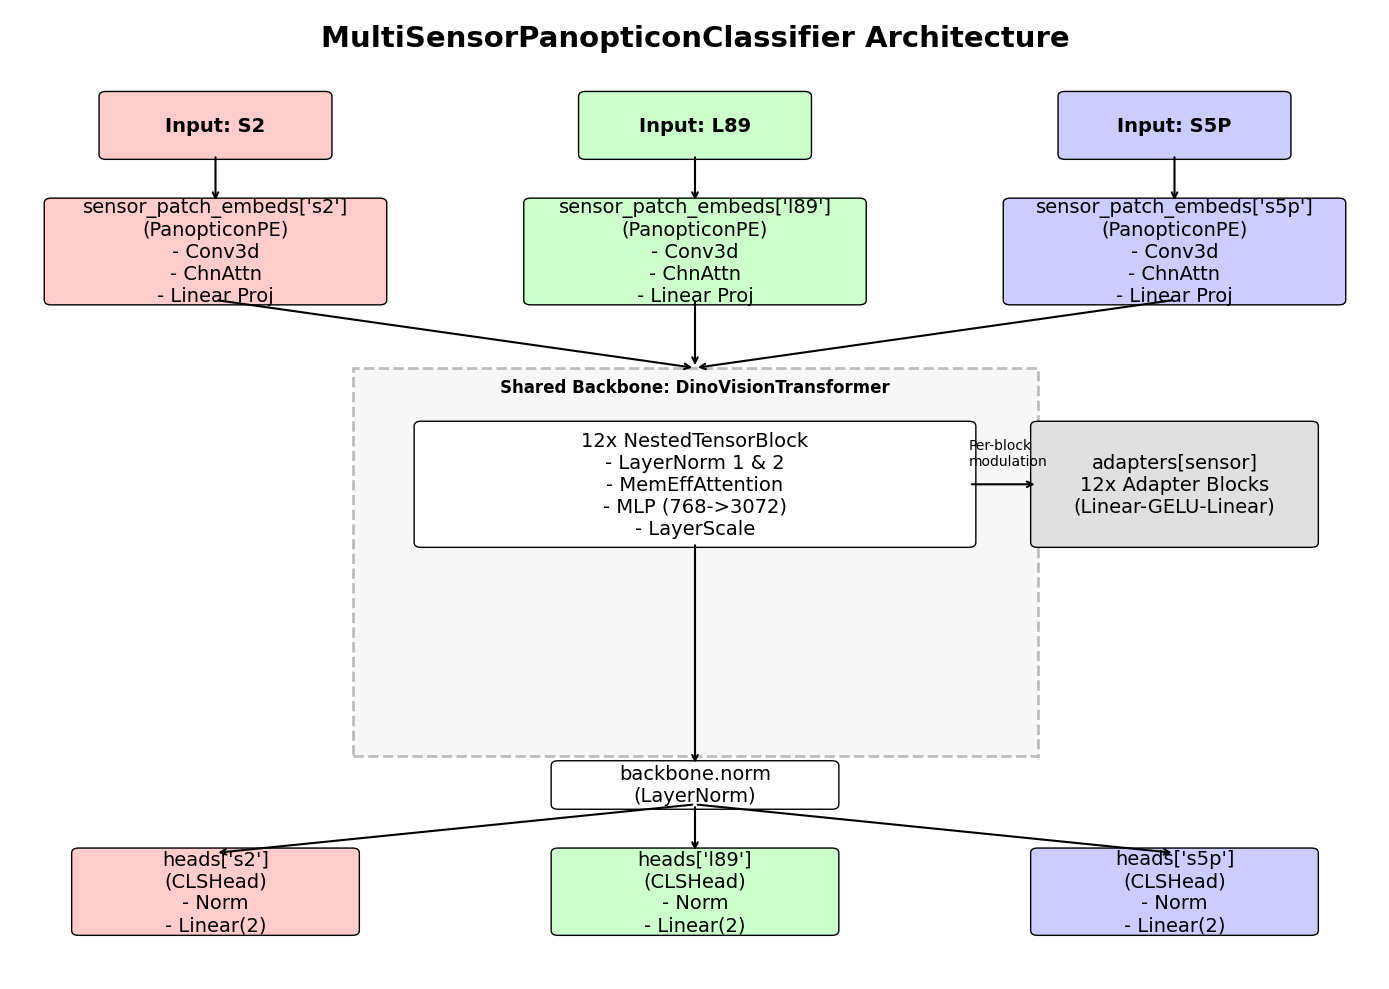

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_model_structure():
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis('off')

    def draw_box(x, y, w, h, text, color='lightblue', fontsize=14, fontweight='normal'):
        rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5", linewidth=1, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, fontweight=fontweight, wrap=True)

    def draw_arrow(x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', lw=1.5))

    # Title
    ax.text(50, 97, 'MultiSensorPanopticonClassifier Architecture', ha='center', va='center', fontsize=21, fontweight='bold')

    # Sensors Inputs
    sensors = ['s2', 'l89', 's5p']
    colors = ['#ffcccc', '#ccffcc', '#ccccff']
    x_positions = [15, 50, 85]
    
    for i, sensor in enumerate(sensors):
        # Input node
        draw_box(x_positions[i]-8, 85, 16, 6, f"Input: {sensor.upper()}", color=colors[i], fontweight='bold')
        
        # Sensor Patch Embed
        pe_y = 70
        draw_box(x_positions[i]-12, pe_y, 24, 10, f"sensor_patch_embeds['{sensor}']\n(PanopticonPE)\n- Conv3d\n- ChnAttn\n- Linear Proj", color=colors[i])
        draw_arrow(x_positions[i], 85, x_positions[i], pe_y + 10)

    # Shared Backbone Block
    backbone_x = 30
    backbone_y = 25
    backbone_w = 40
    backbone_h = 35
    
    # Large container for Backbone
    rect_backbone = patches.Rectangle((backbone_x-5, backbone_y-2), backbone_w+10, backbone_h+5, linewidth=2, edgecolor='gray', facecolor='#f0f0f0', linestyle='--', alpha=0.5)
    ax.add_patch(rect_backbone)
    ax.text(backbone_x + backbone_w/2, backbone_y + backbone_h + 1, 'Shared Backbone: DinoVisionTransformer', ha='center', va='center', fontsize=12, fontweight='bold')

    # Representing the 12 blocks
    draw_box(backbone_x, backbone_y + 20, backbone_w, 12, "12x NestedTensorBlock\n- LayerNorm 1 & 2\n- MemEffAttention\n- MLP (768->3072)\n- LayerScale", color='white')
    
    # Adapters (Representing as a side block linked to backbone)
    adapter_x = 75
    draw_box(adapter_x, backbone_y + 20, 20, 12, "adapters[sensor]\n12x Adapter Blocks\n(Linear-GELU-Linear)", color='#e0e0e0')
    draw_arrow(backbone_x + backbone_w, backbone_y + 26, adapter_x, backbone_y + 26)
    ax.text(backbone_x + backbone_w, backbone_y + 28, "Per-block\nmodulation", fontsize=10)

    # Arrows from PEs to Backbone
    for x in x_positions:
        draw_arrow(x, 70, 50, backbone_y + backbone_h + 3)

    # Backbone Norm
    draw_box(40, 18, 20, 4, "backbone.norm\n(LayerNorm)", color='white')
    draw_arrow(50, backbone_y + 20, 50, 22)

    # Sensor-specific Heads
    head_y = 5
    for i, sensor in enumerate(sensors):
        draw_box(x_positions[i]-10, head_y, 20, 8, f"heads['{sensor}']\n(CLSHead)\n- Norm\n- Linear(2)", color=colors[i])
        # Arrows from Norm to heads
        draw_arrow(50, 18, x_positions[i], head_y + 8)

    plt.tight_layout()
    plt.savefig('model_structure.png', dpi=300)

draw_model_structure()

In [2]:
from graphviz import Digraph

def create_emit_l9_pipeline():
    dot = Digraph('EMIT_to_L9_Pipeline', comment='Simulation Pipeline')
    dot.attr(rankdir='TB', size='8,10')
    dot.attr('node', shape='box', style='filled', fontname='Arial', color='lightblue')

    # --- Input Stage ---
    with dot.subgraph(name='cluster_0') as c:
        c.attr(label='1. Data Ingestion', style='dashed')
        c.node('emit', 'EMIT Reflectance Cube\n(Hyperspectral)', fillcolor='#e1f5fe')
        c.node('filter', 'Filter & Crop\n(Lat 30-35, ±0.15°)', fillcolor='#e1f5fe')

    # --- Spectral Stage ---
    with dot.subgraph(name='cluster_1') as c:
        c.attr(label='2. Spectral Domain Conversion', style='dashed')
        c.node('srf', 'Landsat-9 SRF\n(landsat9_oli_srf.csv)', fillcolor='#fff9c4')
        c.node('interp', 'Interpolate SRF to\nEMIT Wavelengths', fillcolor='#fff9c4')
        c.node('matmul', 'CuPy GPU Matmul\n(Bandpass Integration)', fillcolor='#ffcc80')

    # --- Radiometric Stage ---
    with dot.subgraph(name='cluster_2') as c:
        c.attr(label='3. Radiometric Alignment', style='dashed')
        c.node('stretch', 'Percentile Stretch\n(1-99%)', fillcolor='#c8e6c9')
        c.node('scale', 'Scale & Offset\n(Match L9 DN)', fillcolor='#c8e6c9')

    # --- Spatial Stage ---
    with dot.subgraph(name='cluster_3') as c:
        c.attr(label='4. Geospatial Processing', style='dashed')
        c.node('utm', 'Reproject to\nLocal UTM', fillcolor='#d1c4e9')
        c.node('kdtree', 'KDTree Resampling\n(60m Grid)', fillcolor='#d1c4e9')

    # --- Output ---
    dot.node('output', 'GeoTIFF\n<plume_id>_sim_L9.tif', shape='component', fillcolor='#ffecb3')

    # Define Edges
    dot.edge('emit', 'filter')
    dot.edge('filter', 'matmul')
    dot.edge('srf', 'interp')
    dot.edge('interp', 'matmul')
    dot.edge('matmul', 'stretch')
    dot.edge('stretch', 'scale')
    dot.edge('scale', 'utm')
    dot.edge('utm', 'kdtree')
    dot.edge('kdtree', 'output')

    return dot

# To render the graph:
pipeline_graph = create_emit_l9_pipeline()
pipeline_graph.render('emit_l9_pipeline', format='png', cleanup=True)

'emit_l9_pipeline.png'

In [ ]:
from graphviz import Digraph

def create_methane_model_plot():
    # 创建有向图，设置高质量属性
    dot = Digraph('Methane_Architecture', format='png')
    dot.attr(dpi='300') # 提高清晰度，适合PPT
    dot.attr(rankdir='LR', nodesep='0.5', ranksep='0.8')
    
    # 统一节点样式：学术扁平化风格
    dot.attr('node', shape='box', style='filled, rounded', 
             fontname='Helvetica', fontsize='12', color='#333333', penwidth='1.5')

    # --- 核心流程节点 ---
    dot.node('In', 'Input Cube\n(Multi-Satellite Patch)', fillcolor='#F5F5F5')
    dot.node('C3D', 'Conv3D\n(Spatiotemporal Feature)', fillcolor='#D1E8FF')
    dot.node('Attn', 'Channel Attention\n(Spectral Weighting)', fillcolor='#D1E8FF')
    dot.node('ViT', 'ViT Backbone\n(Global Context)', fillcolor='#E6E6FA')
    
    # 用一个子图（Sub-graph）来展示你正在做的 Adapter 改进
    with dot.subgraph(name='cluster_adapter') as c:
        c.attr(label='Proposed: Domain Adapters', fontname='Helvetica-Bold', 
               color='red', style='dashed', fontcolor='red')
        c.node('A1', 'Adapter (S2)', fillcolor='#FFF0F0')
        c.node('A2', 'Adapter (L8/9)', fillcolor='#FFF0F0')
        c.node('A3', 'Adapter (S5P)', fillcolor='#FFF0F0')

    dot.node('Head', 'CLS Head\n(Methane Detection)', fillcolor='#E1FFD1')

    # --- 连接线 ---
    dot.edge('In', 'C3D')
    dot.edge('C3D', 'Attn')
    dot.edge('Attn', 'ViT')
    
    # 连接到各个 Adapter
    dot.edge('ViT', 'A1')
    dot.edge('ViT', 'A2')
    dot.edge('ViT', 'A3')
    
    # 汇总到输出
    dot.edge('A1', 'Head')
    dot.edge('A2', 'Head')
    dot.edge('A3', 'Head')

    # 保存图片而不自动打开预览
    dot.render('methane_model_arch', cleanup=True)
    print("图片已生成：methane_model_arch.png")

if __name__ == "__main__":
    try:
        create_methane_model_plot()
    except Exception as e:
        print(f"如果依然报错，请确保系统已安装 Graphviz 软件 (brew install graphviz 或 apt install graphviz)")

图片已生成：methane_model_arch.png
